In [1]:
!pip install -q ipywidgets
!apt-get install -q -y graphviz graphviz-dev && pip install -q pydot
!pip install -q pygraphviz

Reading package lists...
Building dependency tree...
Reading state information...
graphviz is already the newest version (2.42.2-6ubuntu0.1).
The following additional packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgtk2.0-0
  libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk libxcomposite1 libxdot4
Suggested packages:
  gvfs
The following NEW packages will be installed:
  libatk1.0-0 libatk1.0-data libgail-common libgail18 libgraphviz-dev
  libgtk2.0-0 libgtk2.0-bin libgtk2.0-common libgvc6-plugins-gtk
  libxcomposite1 libxdot4
0 upgraded, 11 newly installed, 0 to remove and 83 not upgraded.
Need to get 2,478 kB of archives.
After this operation, 7,871 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-data all 2.36.0-3build1 [2,824 B]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libatk1.0-0 amd64 2.36.0-3build1 [51.9 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy-updates/main am

In [2]:
## -- System dependencies --
import tensorflow as tf
import sys, os, gc
import torch
import pydot

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [3]:
# os.environ['KERAS_BACKEND'] = 'tensorflow'

In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools
import shutil

## -- Machine Learning --
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler, TargetEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

tf.get_logger().setLevel('ERROR')
warnings.filterwarnings("ignore", message="Setting the random state for TF")

In [5]:
## -- Global Settings --
# import sklearn
# sklearn.set_config(transform_output='pandas')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
CFG = {
    'FOLDS': 5,
    'SEED': 42,
    'GREEN': '\033[32m',
    'YELLOW': '\033[33m',
    'RESET': '\033[0m'
}

tf.keras.utils.set_random_seed(CFG['SEED'])

print(f"CLASSIC {CFG['GREEN']} GREEN {CFG['RESET']} {CFG['YELLOW']} YELLOW {CFG['RESET']}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e7/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')

    ORIG_PATH = '/kaggle/input/datasets/ziya07/college-student-health-behavior-dataset/'
    orig = pd.read_csv(ORIG_PATH+'student_health_dataset_50k.csv')
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/-- shared_notebooks --/Ps6e7 | Student Health/_student_health_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv')
    test = pd.read_csv(PATH+'test.csv')
    orig = pd.read_csv(PATH+'student_health_dataset_50k.csv')

## =================================================================================

ID = 'id'
TARGET  = 'health_condition'
OBJECTS = train.select_dtypes(include=['object', 'category']).columns.tolist()

CATS = [c for c in OBJECTS if c not in [TARGET, ID]]
NUMS = [c for c in train.columns if c not in CATS+[TARGET, ID]]
BASE = NUMS + CATS

NUM_CLASSES = train[TARGET].nunique()

## -- Fill categorical --
train[CATS] = train[CATS].fillna('missing')
test[CATS]  = test[CATS].fillna('missing')
orig[CATS]  = orig[CATS].fillna('missing')

# {c: i for i, c in enumerate(train[TARGET].unique())}
mapping   = {'fit': 0, 'at-risk': 1, 'unhealthy': 2}
r_mapping = {v: k for k, v in mapping.items()}

train[TARGET] = train[TARGET].map(mapping)
orig[TARGET]  = orig[TARGET].map(mapping)

for (name, df) in {'Train': train, 'Test': test, 'Orig': orig}.items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (690088, 15)
Test shape: (295753, 14)
Orig shape: (50000, 16)

Total Numerical: 7
Total Categorical: 6
Total base features: 13


In [7]:
display(train.head())
train.info()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,missing,average,sedentary,missing,male


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  int64  
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                690088 non-null  object 
 10  stress_level             690088 non-null  object 
 11  sleep_quality            690088 non-null  object 
 12  physical_activity_level  690088 non-null  object 
 13  smoking_alcohol          690088 non-null  object 
 14  gend

In [8]:
train.describe() 

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
count,690088.00000,690088.000000,614089.000000,682255.000000,676190.000000,637235.000000,676172.000000,683187.000000,646611.000000
mean,345043.50000,1.025969,6.992597,75.096504,22.984925,2226.084931,8615.953050,38.751456,2.188542
std,199211.39062,0.375035,1.215407,8.175106,2.481787,347.532098,3929.399831,14.742189,0.518489
min,0.00000,0.000000,3.000000,50.000000,16.000000,1200.000000,1002.000000,0.000000,0.500000
25%,172521.75000,1.000000,6.160000,69.400000,21.320000,2053.000000,5389.000000,29.200000,1.840000
50%,345043.50000,1.000000,6.990000,75.100000,22.990000,2241.000000,8856.000000,39.400000,2.170000
75%,517565.25000,1.000000,7.810000,80.700000,24.660000,2456.000000,12114.000000,49.400000,2.500000
max,690087.00000,2.000000,10.000000,107.700000,34.820000,3580.000000,14999.000000,99.800000,4.720000


In [9]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
Train,701,537,1596,2101,12807,856,400,4,4,4,4,4,4
Original,700,585,1627,2179,13601,1041,412,3,3,3,3,3,3
Test,692,526,1548,2068,12196,817,392,4,4,4,4,4,4


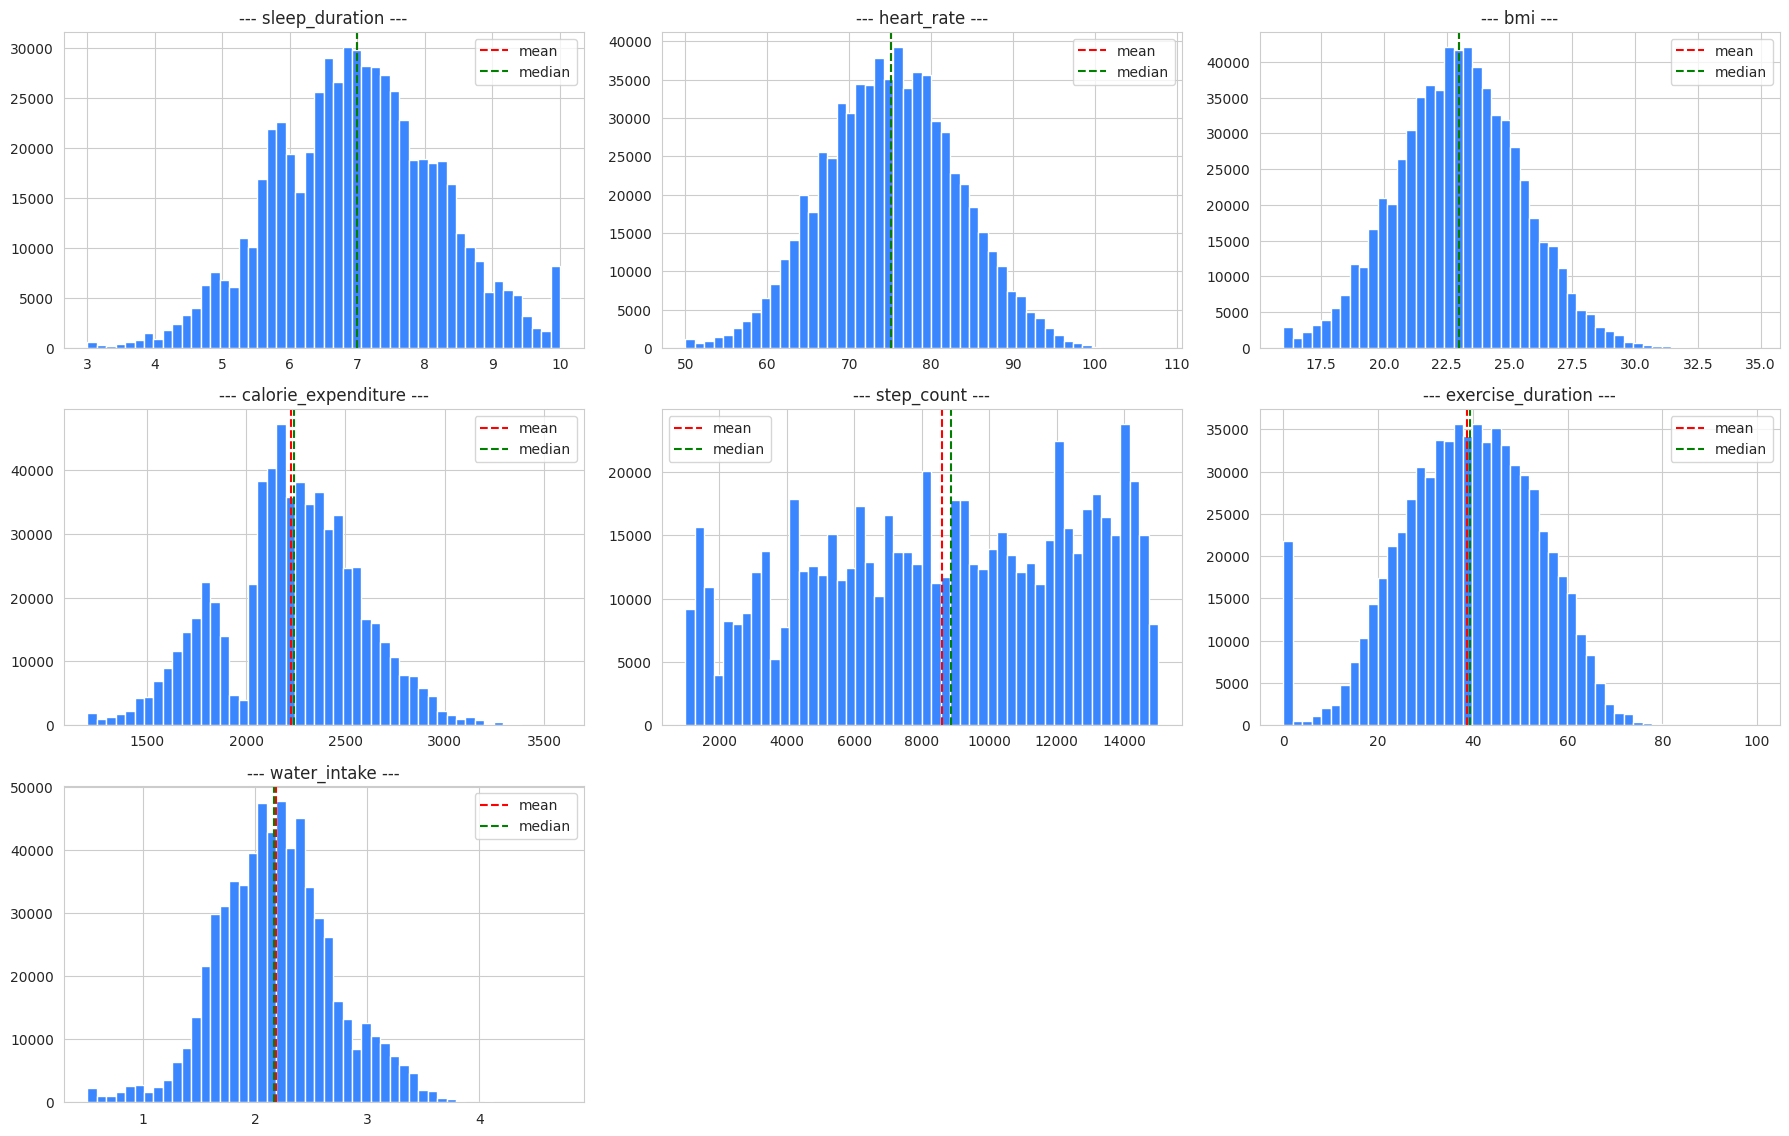

In [10]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(train[col], bins=50)
    plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'--- {col} ---')
    plt.legend()

plt.tight_layout()
plt.show()

## FEATURE ENGINEERING

In [11]:
def get_class_weights(y):
    """
    y: Current y labels -> numpy array or series
    """
    cls_ = np.unique(y)
    wts_ = compute_class_weight("balanced", classes=cls_, y=y)
    return dict(zip(cls_, wts_))

def get_sample_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        return np.array([opt[label] for label in y])
    else:
        cls_ = np.unique(y_true)
        wts_ = compute_class_weight('balanced', classes=cls_, y=y_true)
        cls_wts = dict(zip(cls_, wts_))
        return np.array([cls_wts[label] for label in y])

def balanced_acc(y_true, y_proba):
    pred_labels = np.argmax(y_proba, axis=1)
    return balanced_accuracy_score(y_true, pred_labels)

def multi_class_brier(y_true, y_proba, classes):
    y_onehot = label_binarize(y_true, classes=classes)
    return float(np.mean(np.sum((y_onehot - y_proba) ** 2, axis=1)))


def t_enc_multi(X_tr, X_va, X_ts, y_tr, cols, drop=False):
    X_tr_1 = X_tr.copy()
    X_va_1 = X_va.copy()
    X_ts_1 = X_ts.copy()

    te_enc = TargetEncoder(target_type='multiclass', random_state=CFG['SEED']).set_output(transform='pandas')

    X_tr_te = te_enc.fit_transform(X_tr_1[cols], y_tr)
    X_va_te = te_enc.transform(X_va_1[cols])
    X_ts_te = te_enc.transform(X_ts_1[cols])

    te_names = [f"TE_{c}" for c in X_tr_te.columns]
    X_tr_1[te_names] = X_tr_te
    X_va_1[te_names] = X_va_te
    X_ts_1[te_names] = X_ts_te

    if drop:
        X_tr_1 = X_tr_1.drop(columns=cols)
        X_va_1 = X_va_1.drop(columns=cols)
        X_ts_1 = X_ts_1.drop(columns=cols)

    return X_tr_1, X_va_1, X_ts_1

print('- Helper functions ready -')

- Helper functions ready -


In [12]:
get_class_weights(train[TARGET])

{np.int64(0): np.float64(5.779195873007898),
 np.int64(1): np.float64(0.38819519565636845),
 np.int64(2): np.float64(3.9849860254544613)}

In [13]:
## -- Extractions & Binnig --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []
 
round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [14]:
# for col in ['redshift']:
#     # print(f"\nRounding... ", end='')
#     for r in range(-3, 6):
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDigitizing... ", end='')
#     # for d in range(1):
#     #     d_n = f'{col}_{d}_digit_'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [32, 64, 128]: # 100, 500, 1000
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nQuantile binning... ", end='')
#     # for q in [32, 64, 128]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [15]:
# for col in ['delta']: # 'u', 'g', 'r', 'i', 'z',
#     # print(f"\nRounding... ", end='')
#     # for r in range(-3, 5):
#     #     r_n = f"{col}_round_{r}"
#     #     print(r_n+', ', end='')
#     #     train[r_n] = train[col].round(r).astype('int32')
#     #     test[r_n]  = test[col].round(r).astype('int32')
#     #     orig[r_n]  = orig[col].round(r).astype('int32')
#     #     ## -- Drop irrelevant features --
#     #     if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#     #         DROP_COLS.append(r_n)
#     #     else:
#     #         ROUNDS.append(r_n)
    
#     # print(f"\nExtracting digits... ", end='')
#     # for d in range(-3, 6):
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nEqual binning... ", end='')
#     # for b in [100]: # 50, 100, 400
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     # Fit on train data and transform both train and test
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)
        
#     print(f"\nQuantile binning.. ", end='')
#     for q in [100]: 
#         q_n = f'{col}_qbin_{q}'
#         print(q_n+', ', end='')
#         train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#         test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#         orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#         Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ ROUNDS: {len(ROUNDS)}')
# print(f"✅ DIGITS: {len(DIGITS)}")
# print(f"✅ E_BINS: {len(E_BINS)}")
# print(f"✅ Q_BINS: {len(Q_BINS)}")

In [16]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [17]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         # 1. Get value counts
#         v_counts = df[c].value_counts()
#         # 2. Identify values to replace (count <= threshold)
#         to_replace = v_counts[v_counts <= thresh].index
#         # 3. Apply condition: if value in low-freq list, assign 0, else keep it
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [18]:
# ## -- Arithmetic interaction --
# BANDS = ['u', 'g', 'r', 'i', 'z']

# prefix = '_arith'
# for df in tqdm([train, test, orig]):
#     df[f"{prefix}_sub_u_g"] = df['u'] - df['g']
#     df[f"{prefix}_sub_g_r"] = df['g'] - df['r']

#     df[f"{prefix}_sub_g_i"] = df['g'] - df['i']
#     df[f"{prefix}_sub_r_z"] = df['r'] - df['z']

#     df[f"{prefix}_sub_i_z"] = df['i'] - df['z']
#     df[f"{prefix}_sub_r_i"] = df['r'] - df['i']
    
#     df[f"{prefix}_stellar_locus_dist"] = np.sqrt((df['_arith_sub_g_r'] - 0.52)**2 \
#                                               + (df['_arith_sub_r_i'] - 0.25)**2)

#     for band in ['g', 'i']:
#         b_col = f"{prefix}_div_{band}_redshift"
#         df[b_col] = df[band] / (df['redshift'] + 1e-6)

#     df[f"{prefix}_sum_bands"]   = df[BANDS].sum(axis=1)
#     df[f"{prefix}_mean_bands"]  = df[BANDS].mean(axis=1)
#     # df[f"{prefix}_max_bands"]   = df[BANDS].max(axis=1)
#     # df[f"{prefix}_min_bands"]   = df[BANDS].min(axis=1)
#     # df[f"{prefix}_range_bands"] = df[BANDS].max(axis=1) - df[BANDS].min(axis=1)

#     # df['_div_sum_bands_redshift'] = df['redshift'] / (df['_sum_bands'] + 1e-6)

# color_bands = [c for c in train.columns if c.startswith(f"{prefix}")]

# train[color_bands].describe()

In [19]:
# train[color_bands].hist(bins=80, figsize=(18, 12))
# plt.tight_layout()
# plt.show()

In [20]:
# ## -- Cyclic encoding --

# for df in [train, test, orig]:
#     for col in ['alpha']:
#         for p in [180, 360]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# for df in [train, test, orig]:
#     for col in ['delta']:
#         for p in [180]:
#             df[f"{col}_{p}_sin_"] = np.sin(2 * np.pi * df[col] / p)
#             df[f"{col}_{p}_cos_"] = np.cos(2 * np.pi * df[col] / p)

# cyclic_cols = [c for c in train.columns if c.endswith('_sin_') or c.endswith('_cos_')]

# train[cyclic_cols].head()

In [21]:
# ## -- Create log-transformed features --
# for df in [train, test, orig]:
#     for col in ['redshift',]:
#         n_log = f"_log_{col}"
#         df[n_log] = np.log1p(df[col])

# log_cols = [c for c in train.columns if c.startswith('_log_')]

# plt.figure(figsize=(16, 5))

# for i, col in enumerate(log_cols):
#     # plt.subplot(2, len(log_cols)//2, i+1)
#     plt.hist(train[col], bins=100)
#     plt.axvline(x=train[col].mean(), color='r', linestyle='--', label='mean')
#     plt.axvline(x=train[col].median(), color='g', linestyle='--', label='median')
#     plt.title(f'{col}', fontweight='semibold')
#     plt.legend()

# plt.tight_layout()
# plt.show()

In [22]:
# ## -- Frequency encoding --
# freq_cols = []

# print(f"\nCreate frequencies... ", end='')
# for col in ['spectral_type']:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_freq'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     freq_cols.append(n)

# print()
# print(f"✅ Total frequency features: {len(freq_cols)}")

# train[freq_cols].head()

In [23]:
# from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/CategoryMean ENCODERS =====

# class TargetEncoder(BaseEstimator, TransformerMixin):
#     """
#     Target Encoder that supports multiple aggregation functions,
#     internal cross-validation for leakage prevention, and smoothing.

#     Parameters
#     ----------
#     cols_to_encode : list of str
#         List of column names to be target encoded.

#     aggs : list of str, default=['mean']
#         List of aggregation functions to apply. Any function accepted by
#         pandas' `.agg()` method is supported, such as:
#         'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
#         'count', 'sum', 'median'.
#         Smoothing is applied only to the 'mean' aggregation.

#     cv : int, default=5
#         Number of folds for cross-validation in fit_transform.

#     smooth : float or 'auto', default='auto'
#         The smoothing parameter `m`. A larger value puts more weight on the
#         global mean. If 'auto', an empirical Bayes estimate is used.

#     drop_original : bool, default=False
#         If True, the original columns to be encoded are dropped.
#     """
#     def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
#         self.cols_to_encode = cols_to_encode
#         self.aggs = aggs
#         self.cv = cv
#         self.smooth = smooth
#         self.drop_original = drop_original
#         self.mappings_ = {}
#         self.global_stats_ = {}

#     def fit(self, X, y):
#         """
#         Learn mappings from the entire dataset.
#         These mappings are used for the transform method on validation/test data.
#         """
#         temp_df = X.copy()
#         temp_df['target'] = y

#         # Learn global statistics for each aggregation
#         for agg_func in self.aggs:
#             self.global_stats_[agg_func] = y.agg(agg_func)

#         # Learn category-specific mappings
#         for col in self.cols_to_encode:
#             self.mappings_[col] = {}
#             for agg_func in self.aggs:
#                 mapping = temp_df.groupby(col)['target'].agg(agg_func)
#                 self.mappings_[col][agg_func] = mapping

#         return self

#     def transform(self, X):
#         """
#         Apply learned mappings to the data.
#         Unseen categories are filled with global statistics.
#         """
#         X_transformed = X.copy()
#         for col in self.cols_to_encode:
#             for agg_func in self.aggs:
#                 new_col_name = f'TE_{col}_{agg_func}'
#                 map_series = self.mappings_[col][agg_func]
#                 X_transformed[new_col_name] = X[col].map(map_series)
#                 X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed

#     def fit_transform(self, X, y):
#         """
#         Fit and transform the data using internal cross-validation to prevent leakage.
#         """
#         # First, fit on the entire dataset to get global mappings for transform method
#         self.fit(X, y)

#         # Initialize an empty DataFrame to store encoded features
#         encoded_features = pd.DataFrame(index=X.index)

#         kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

#         for train_idx, val_idx in kf.split(X, y):
#             X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
#             X_val = X.iloc[val_idx]

#             temp_df_train = X_train.copy()
#             temp_df_train['target'] = y_train

#             for col in self.cols_to_encode:
#                 # --- Calculate mappings only on the training part of the fold ---
#                 for agg_func in self.aggs:
#                     new_col_name = f'TE_{col}_{agg_func}'

#                     # Calculate global stat for this fold
#                     fold_global_stat = y_train.agg(agg_func)

#                     # Calculate category stats for this fold
#                     mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

#                     # --- Apply smoothing only for 'mean' aggregation ---
#                     if agg_func == 'mean':
#                         counts = temp_df_train.groupby(col)['target'].count()

#                         m = self.smooth
#                         if self.smooth == 'auto':
#                             # Empirical Bayes smoothing
#                             variance_between = mapping.var()
#                             avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
#                             if variance_between > 0:
#                                 m = avg_variance_within / variance_between
#                             else:
#                                 m = 0  # No smoothing if no variance between groups

#                         # Apply smoothing formula
#                         smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
#                         encoded_values = X_val[col].map(smoothed_mapping)
#                     else:
#                         encoded_values = X_val[col].map(mapping)

#                     # Store encoded values for the validation fold
#                     encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

#         # Merge with original DataFrame
#         X_transformed = X.copy()
#         for col in encoded_features.columns:
#             X_transformed[col] = encoded_features[col]

#         if self.drop_original:
#             X_transformed.drop(columns=self.cols_to_encode, inplace=True)

#         return X_transformed


# class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
#     def __init__(self, cat_cols=None):
#         self.cat_cols = cat_cols
#         self.mappings_ = {}
#     def fit(self, X, y):
#         X = X.copy()
#         if self.cat_cols is None:
#             self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
#         self.mappings_ = {}
#         for col in self.cat_cols:
#             df_temp = pd.DataFrame({col: X[col], 'y': y})
#             group_means = df_temp.groupby(col, dropna=False)['y'].mean()
#             sorted_categories = group_means.sort_values().index
#             self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
#         return self

#     def transform(self, X, y=None):
#         X = X.copy()
#         for col, mapping in self.mappings_.items():
#             if col in X.columns:
#                 X[col] = X[col].map(mapping)
#         return X

In [24]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col)) #.astype('int32')
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [25]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+ROUNDS+DIGITS, #+ROUNDS,
#     target=TARGET,
#     aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

In [26]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []

# for c in ['delta']:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     orig[n]  = orig[c].copy()
#     CATS_2.append(n)

#     # ## -- FACTORIZE CATS_2 --
#     # combine  = pd.concat([train[n], test[n], orig[n]])
#     # v = combine.factorize()[0]
#     # train[n] = v[:len(train)].astype('int32')
#     # test[n]  = v[len(train):len(train)+len(test)].astype('int32')
#     # orig[n]  = v[len(train)+len(test):].astype('int32')

# print(f'Nums to Cats: {len(CATS_2)}')
# CATS_2

In [27]:
# ## -- Factorize using combined data --
# for c in CATS:
#     combine  = pd.concat([train[c], test[c], orig[c]])
#     combine  = combine.factorize()[0]
#     # combine  = pd.Series(combine).astype('category')
#     train[c] = combine[:len(train)]
#     test[c]  = combine[len(train):len(train)+len(test)]
#     orig[c]  = combine[-len(orig):]

# print('Label encoding complete!')

In [28]:
FEATURES = [c for c in train.columns if c not in [ID, TARGET]]
print("Total Features:", len(FEATURES))

train

Total Features: 13


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,missing,average,sedentary,missing,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,missing,average,active,no,male
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,missing,average,active,yes,male


# ML TRAINING

In [29]:
from tensorflow.keras.utils import FeatureSpace
from tensorflow.keras import layers, Sequential

def build_keras_model(
    feature_space: tf.keras.utils.FeatureSpace=None,
    num_classes=None,
    activation="relu",
    units=[256, 128, 64],
    lr=1e-2,
    drop=0.3,
    **kwargs
    ):

    kernel_reg = tf.keras.regularizers.L2(0.0)
    use_bias = True

    ## - 1. Setup inputs
    dict_inputs = feature_space.get_inputs()
    encoded_features = feature_space.get_encoded_features()

    print(f"{CFG['YELLOW']}Inputs: {len(dict_inputs)} | FS_encoded: {encoded_features.shape}")
    print(f"{CFG['RESET']}")

    ## - 2. Create Sequential model
    mlp_head = Sequential([
        ## -- 1st Layer --
        layers.Dense(units[0], activation, use_bias=use_bias, kernel_regularizer=kernel_reg),
        layers.BatchNormalization(),
        layers.Dropout(drop),
    
        ## -- 2nd Layer --
        layers.Dense(units[1], activation, use_bias=use_bias, kernel_regularizer=kernel_reg),
        layers.BatchNormalization(),
        layers.Dropout(drop),
    
        ## -- 3rd Layer --
        layers.Dense(units[2], activation, use_bias=use_bias, kernel_regularizer=kernel_reg),
        layers.BatchNormalization(),
        layers.Dropout(drop),
        
        ## -- Output --
        layers.Dense(num_classes, activation="softmax") 
    ])

    # 3. Connect everything
    outputs = mlp_head(encoded_features)
    train_model = tf.keras.Model(inputs=encoded_features, outputs=outputs)

    # 4. Compile
    train_model.compile(
        optimizer=tf.keras.optimizers.Adam(lr, weight_decay=0.0),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(name="loss"),
        metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")]
    )

    infer_model = tf.keras.Model(inputs=dict_inputs, outputs=outputs)

    return train_model, infer_model

print("⚙️ Keras model ready ⚙️")

⚙️ Keras model ready ⚙️


In [30]:
## -- Define Trainer --
class TrainerCV:
    def __init__(
        self,
        model_builder, # function -> tf.keras.Model
        model_name: str,
        train_df: pd.DataFrame,
        test_df: pd.DataFrame,
        features: list,
        target: str,
        kfold, # StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        batch_size: int=32,
        epochs: int=10,
        patience: int=3,
        activation: str='relu',
        learning_rate: float=1e-2,
        dropout: float=0.3,
        units = [256, 128, 64],
        eval_metric: str='val_loss', 
        **kwargs
    ):
        self.model_builder = model_builder
        self.model_name = model_name
        self.train_df = train_df
        self.test_df = test_df
        self.features = features
        self.target = target
        self.kfold = kfold
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.activation = activation
        self.learning_rate = learning_rate
        self.dropout = dropout
        self.units = units
        self.eval_metric = eval_metric

        self.result = None
    
    # def _prepare_fold_data(self, X, y, X_val=None, y_val=None):
    #     # This helper can be extended to apply masks or augmentations.
    #     return X, y

    # def _df_to_ds(self, df_full, target, batch_input):
    #     df = df_full.copy()
    #     labels = df.pop(target)
    #     ds = tensorflow.data.Dataset.from_tensor_slices((dict(df), labels))
    #     ds = ds.batch(batch_input)
    #     return ds

    def _feature_space_transform(self, train_full, batch_input):
        feature_specs = {}

        ## -- Handle cat strings --
        for col in CATS: # or [c for c in BASE if train_full[c].dtype == 'object']
            feature_specs[col] = FeatureSpace.string_categorical(num_oov_indices=0)

        # ## -- Handle cat integers --
        # for col in ['delta', 'alpha']:
        #     feature_specs[col] = FeatureSpace.float_discretized(num_bins=64)
        #     # feature_specs[col] = FeatureSpace.integer_categorical(num_oov_indices=1)

        ## -- Handle continuous --
        for col in NUMS:
            feature_specs[col] = FeatureSpace.float()
            # feature_specs[col] = FeatureSpace.float_normalized()
            # feature_specs[col] = FeatureSpace.float_discretized(num_bins=32)
            # feature_specs[col] = FeatureSpace.float_rescaled(
            #     scale=1.0 / (train_data[col].max() - train_data[col].min()),
            #     offset=-train_data[col].min() / (train_data[col].max() - train_data[col].min())
            #     )

        # ## -- Handle regular floats --
        # for col in log_cols: 
        #     feature_specs[col] = FeatureSpace.float()
        #     # feature_specs[col] = FeatureSpace.float_normalized()

        # ## -- Handle regular floats --
        # for col in cyclic_cols: 
        #     feature_specs[col] = FeatureSpace.float()
        #     # feature_specs[col] = FeatureSpace.float_normalized()

        # ## -- Handle continuous --
        # for col in color_bands:
        #     # feature_specs[col] = FeatureSpace.float()
        #     feature_specs[col] = FeatureSpace.float_normalized()

        # feature_crosses = []
        # for c1, c2 in itertools.combinations(CATS, 2):
        #     feature_crosses.append(FeatureSpace.cross((c1, c2), crossing_dim=2))

        # for c1, c2 in itertools.product(TOP_COLS, LOW_COLS):
        #     feature_crosses.append(FeatureSpace.cross((c1, c2), crossing_dim=8))

        _fs = FeatureSpace(
            features=feature_specs,
            # crosses=feature_crosses,
            output_mode='concat',
            name='feature_processed',
        )

        print(f"⚙️ Adapting FeatureSpace.adapt() to features... ", end='')

        x = train_full[self.features]
        y = train_full[self.target]

        ds = tf.data.Dataset.from_tensor_slices((dict(x), y)).batch(batch_input)
        no_labels = ds.map(lambda x, _: x)

        _fs.adapt(no_labels)

        print(f"✅ Complete!\n")
        return _fs

    # def _convert_infer_dict(self, X):
    #     if type(X) != 'dict':
    #         X = {name: tensorflow.convert_to_tensor([value]) for name, value in dict(X).items()}

    #     return X

    def fit(self):
        train_df = self.train_df
        test_df  = self.test_df
        features = self.features
        target   = self.target

        print(f"\n===== Starting CV: {self.model_name} =====")
        start = time()

        num_cls = train_df[target].nunique()

        self.oof_preds  = np.zeros((len(train_df), num_cls))
        self.test_preds = np.zeros((len(test_df), num_cls))
        self.fold_scores = []
        self.fold_histories = []

        X = train_df[features]
        y = train_df[target]

        strategy = tf.distribute.MirroredStrategy()
        GLOBAL_BATCH_SIZE = self.batch_size * strategy.num_replicas_in_sync
        print('⚙️ Number of devices: {}'.format(strategy.num_replicas_in_sync))

        feature_space_module = self._feature_space_transform(self.train_df, GLOBAL_BATCH_SIZE)

        for idx, (train_idx, val_idx) in enumerate(self.kfold.split(X, y), 1):
            print(f"\n{"="*50}")
            print(f"• FOLD {idx}/{self.kfold.n_splits}")

            X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
            X_test = test_df[features].copy()

            ## -- Standardized data --
            for col in NUMS:
                scaler = StandardScaler()
                X_train[col] = scaler.fit_transform(X_train[[col]])
                X_valid[col] = scaler.transform(X_valid[[col]])
                X_test[col]  = scaler.transform(X_test[[col]])

                imputer = IterativeImputer(max_iter=10, tol=1e-5, random_state=0)
                X_train[col] = imputer.fit_transform(X_train[[col]])
                X_valid[col] = imputer.transform(X_valid[[col]])
                X_test[col]  = imputer.transform(X_test[[col]])

            ## -- Create tf.data.Datasets for train and valid --
            X_train_ds = tf.data.Dataset.from_tensor_slices((dict(X_train), y_train)).batch(GLOBAL_BATCH_SIZE)\
                           .map(lambda x, y: (feature_space_module(x), y), num_parallel_calls=tf.data.AUTOTUNE)\
                           .prefetch(tf.data.AUTOTUNE)

            X_valid_ds = tf.data.Dataset.from_tensor_slices((dict(X_valid), y_valid)).batch(GLOBAL_BATCH_SIZE)\
                           .map(lambda x, y: (feature_space_module(x), y), num_parallel_calls=tf.data.AUTOTUNE)\
                           .prefetch(tf.data.AUTOTUNE)

            ## -- Build model --
            train_model, infer_model = self.model_builder(
                feature_space=feature_space_module,
                num_classes=num_cls,
                activation=self.activation,
                units=self.units,
                lr=self.learning_rate,
                dropout=self.dropout,
                **{} # pass additional hyperparams if needed --
            )

            ## -- Define callbacks --
            callbacks = [
                tf.keras.callbacks.EarlyStopping(
                    monitor=self.eval_metric,
                    mode="max",
                    patience=self.patience,
                    restore_best_weights=True,
                ),
                # tf.keras.callbacks.ReduceLROnPlateau(
                #     monitor=self.eval_metric,
                #     mode='max',
                #     factor=0.5,
                #     patience=self.patience,
                #     min_lr=1e-6,
                #     verbose=1,
                # ),
                tf.keras.callbacks.ModelCheckpoint( # -> save model
                    filepath=f"{CHECKPOINT}best_model.model.keras",
                    monitor=self.eval_metric,
                    save_best_only=True,
                    # verbose=1
                ),
                tf.keras.callbacks.ModelCheckpoint( # -> save weights
                    filepath=f"{CHECKPOINT}best_model.weights.h5",
                    monitor=self.eval_metric,
                    save_best_only=True,
                    save_weights_only=True,
                ),
            ]

            ## -- Fit model --
            history = train_model.fit(
                X_train_ds,
                validation_data=X_valid_ds,
                class_weight=get_class_weights(y_train),
                epochs=self.epochs,
                callbacks=callbacks,
                verbose=2,
            )
            self.fold_histories.append(history.history)

            ## -- Make predictions with infer_model --
            X_val_ds = tf.data.Dataset.from_tensor_slices(dict(X_valid)).batch(GLOBAL_BATCH_SIZE)
            self.oof_preds[val_idx] = infer_model.predict(X_val_ds)

            fold_score = balanced_acc(y_valid, self.oof_preds[val_idx])
            self.fold_scores.append(fold_score)
            print(f"{CFG['YELLOW']} • Fold {idx} Score: {fold_score:.5f}{CFG['RESET']}")

            X_test_ds = tf.data.Dataset.from_tensor_slices(dict(X_test)).batch(GLOBAL_BATCH_SIZE)
            self.test_preds += infer_model.predict(X_test_ds)

            ## -- Save fold infer_model --
            infer_model.save(f"{CHECKPOINT}infer_model_{idx}.keras")

        self.test_preds /= self.kfold.n_splits

        ## -- Print final cross-validation results --
        print("\n==================================================")
        print(f"{self.kfold.n_splits}-FOLD CV: {self.model_name}")
        print("==================================================")
        for i, score in enumerate(self.fold_scores, 1):
            print(f" • Fold {i}: {score:.5f}")

        oof_score = np.round(balanced_acc(y, self.oof_preds), 5)
        avg_score = np.round(np.mean(self.fold_scores), 5)
        std_score = np.round(np.std(self.fold_scores), 5)

        print("-------------------------------------------------|")
        print(f"OOF Score: {oof_score}")
        print(f"AVG Score: {avg_score} ± {std_score}")
        print("-------------------------------------------------|")
        print(f'{((time() - start) / 60):.2f} mins\n')

        print()
        display(train_model.summary(expand_nested=True))

        return {
            'avg_score': avg_score,
            'oof_score': oof_score,
            'fold_scores': self.fold_scores,
            'oof_preds': self.oof_preds,
            'test_preds': self.test_preds,
            'val_data': [X_val_ds, y_valid],
            'history': self.fold_histories,
        }

print("⚙️ Model trainer ready ⚙️")


⚙️ Model trainer ready ⚙️


In [31]:
!rm -r /kaggle/working

rm: cannot remove '/kaggle/working': Device or resource busy


In [32]:
!rm -r {CHECKPOINT}

rm: cannot remove '{CHECKPOINT}': No such file or directory


In [33]:
if PLATFORM == 'kaggle':
    CHECKPOINT = '/kaggle/working/checkpoints/'
elif PLATFORM == 'colab':
    CHECKPOINT = '/content/checkpoints'

!mkdir {CHECKPOINT}

print(f"☑️ Checkpoint directory: {CHECKPOINT}")

☑️ Checkpoint directory: /kaggle/working/checkpoints/


In [34]:
all_predictions = {}

USE_FULL_TRAIN = True

CFG['FOLDS'] = 5
skf = StratifiedKFold(n_splits=CFG['FOLDS'], shuffle=True, random_state=CFG['SEED'])

x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
train_data = train.copy() if USE_FULL_TRAIN else x_sample.copy()

train_data

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,2,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,2,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,1,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,missing,average,sedentary,missing,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690083,690083,1,6.31,69.7,24.11,2157.0,NaN,30.8,3.00,non-veg,high,poor,active,yes,female
690084,690084,1,5.78,54.0,26.36,2858.0,6488.0,52.4,1.46,veg,medium,average,moderate,no,male
690085,690085,0,7.64,85.7,21.91,2195.0,9241.0,41.3,1.57,non-veg,missing,average,active,no,male
690086,690086,1,6.74,73.0,18.73,2061.0,13366.0,56.6,2.60,balanced,missing,average,active,yes,male


In [35]:
%%time

LR         = 0.001
EPOCHS     = 150
PATIENCE   = 10
BATCH_SIZE = 64
DROPOUT    = 0.3
DIMENSIONS = [128, 256, 64]
ACTIVATION = 'relu'
VAL_METRIC = 'val_accuracy'

VERS = f"kerasFS"

# for i, VALUE in enumerate([0.4, 0.5], 1):
trainer = TrainerCV(
    model_builder = build_keras_model,
    model_name    = VERS,
    train_df      = train_data,
    test_df       = test,
    features      = FEATURES,
    target        = TARGET,
    kfold         = skf,
    learning_rate = LR,
    dropout       = DROPOUT,
    activation    = ACTIVATION,
    batch_size    = BATCH_SIZE,
    epochs        = EPOCHS,
    units         = DIMENSIONS,
    patience      = PATIENCE,
    eval_metric   = VAL_METRIC,
)

result = trainer.fit()
    # all_predictions[f"{VERS}_{str(VALUE)}"] = result["final_score"]


===== Starting CV: kerasFS =====
⚙️ Number of devices: 1
⚙️ Adapting FeatureSpace.adapt() to features... 

2026-07-11 00:05:04.021074: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


✅ Complete!


• FOLD 1/5
Inputs: 13 | FS_encoded: (None, 31)

Epoch 1/150
8627/8627 - 49s - 6ms/step - accuracy: 0.8682 - loss: 0.2961 - val_accuracy: 0.9249 - val_loss: 0.2579
Epoch 2/150
8627/8627 - 47s - 5ms/step - accuracy: 0.9121 - loss: 0.2375 - val_accuracy: 0.9248 - val_loss: 0.2286
Epoch 3/150
8627/8627 - 48s - 6ms/step - accuracy: 0.9204 - loss: 0.2207 - val_accuracy: 0.9218 - val_loss: 0.2263
Epoch 4/150
8627/8627 - 48s - 6ms/step - accuracy: 0.9224 - loss: 0.2147 - val_accuracy: 0.9250 - val_loss: 0.2211
Epoch 5/150
8627/8627 - 47s - 5ms/step - accuracy: 0.9237 - loss: 0.2103 - val_accuracy: 0.9263 - val_loss: 0.2165
Epoch 6/150
8627/8627 - 47s - 5ms/step - accuracy: 0.9246 - loss: 0.2087 - val_accuracy: 0.9246 - val_loss: 0.2164
Epoch 7/150
8627/8627 - 47s - 5ms/step - accuracy: 0.9252 - loss: 0.2064 - val_accuracy: 0.9263 - val_loss: 0.2159
Epoch 8/150
8627/8627 - 47s - 5ms/step - accuracy: 0.9261 - loss: 0.2053 - val_accuracy: 0.9248 - val_loss: 0.2131
Epoch 9/150
8627/8

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_19CLONE            │ (None, 31)             │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 3)              │        55,555 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_16 (Dense)           │ (None, 128)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_12     │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_12 (Dropout)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_17 (Dense)           │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_13     │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_13 (Dropout)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_18 (Dense)           │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_14     │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout_14 (Dropout)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense_19 (Dense)           │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 54,659 (213.51 KB)

 Non-trainable params: 896 (3.50 KB)

 Optimizer params: 109,320 (427.04 KB)

None

CPU times: user 2h 36min 51s, sys: 14min 5s, total: 2h 50min 57s
Wall time: 1h 16min 53s


In [36]:
all_predictions

{}

In [37]:
result['oof_score']

np.float64(0.92988)

In [38]:
# ==================================================
# 5-FOLD CV: kerasFS_[128, 256, 64] | Inputs: 13 | FS_encoded: (None, 31)
# drop=0.3 | lr=0.01
# ==================================================
#  • Fold 1: 0.92504
#  • Fold 2: 0.93963
#  • Fold 3: 0.93811
#  • Fold 4: 0.92373
#  • Fold 5: 0.94038
# -------------------------------------------------|
# OOF Score: 0.93338
# AVG Score: 0.93338 ± 0.00739
# -------------------------------------------------|
# 14.93 mins

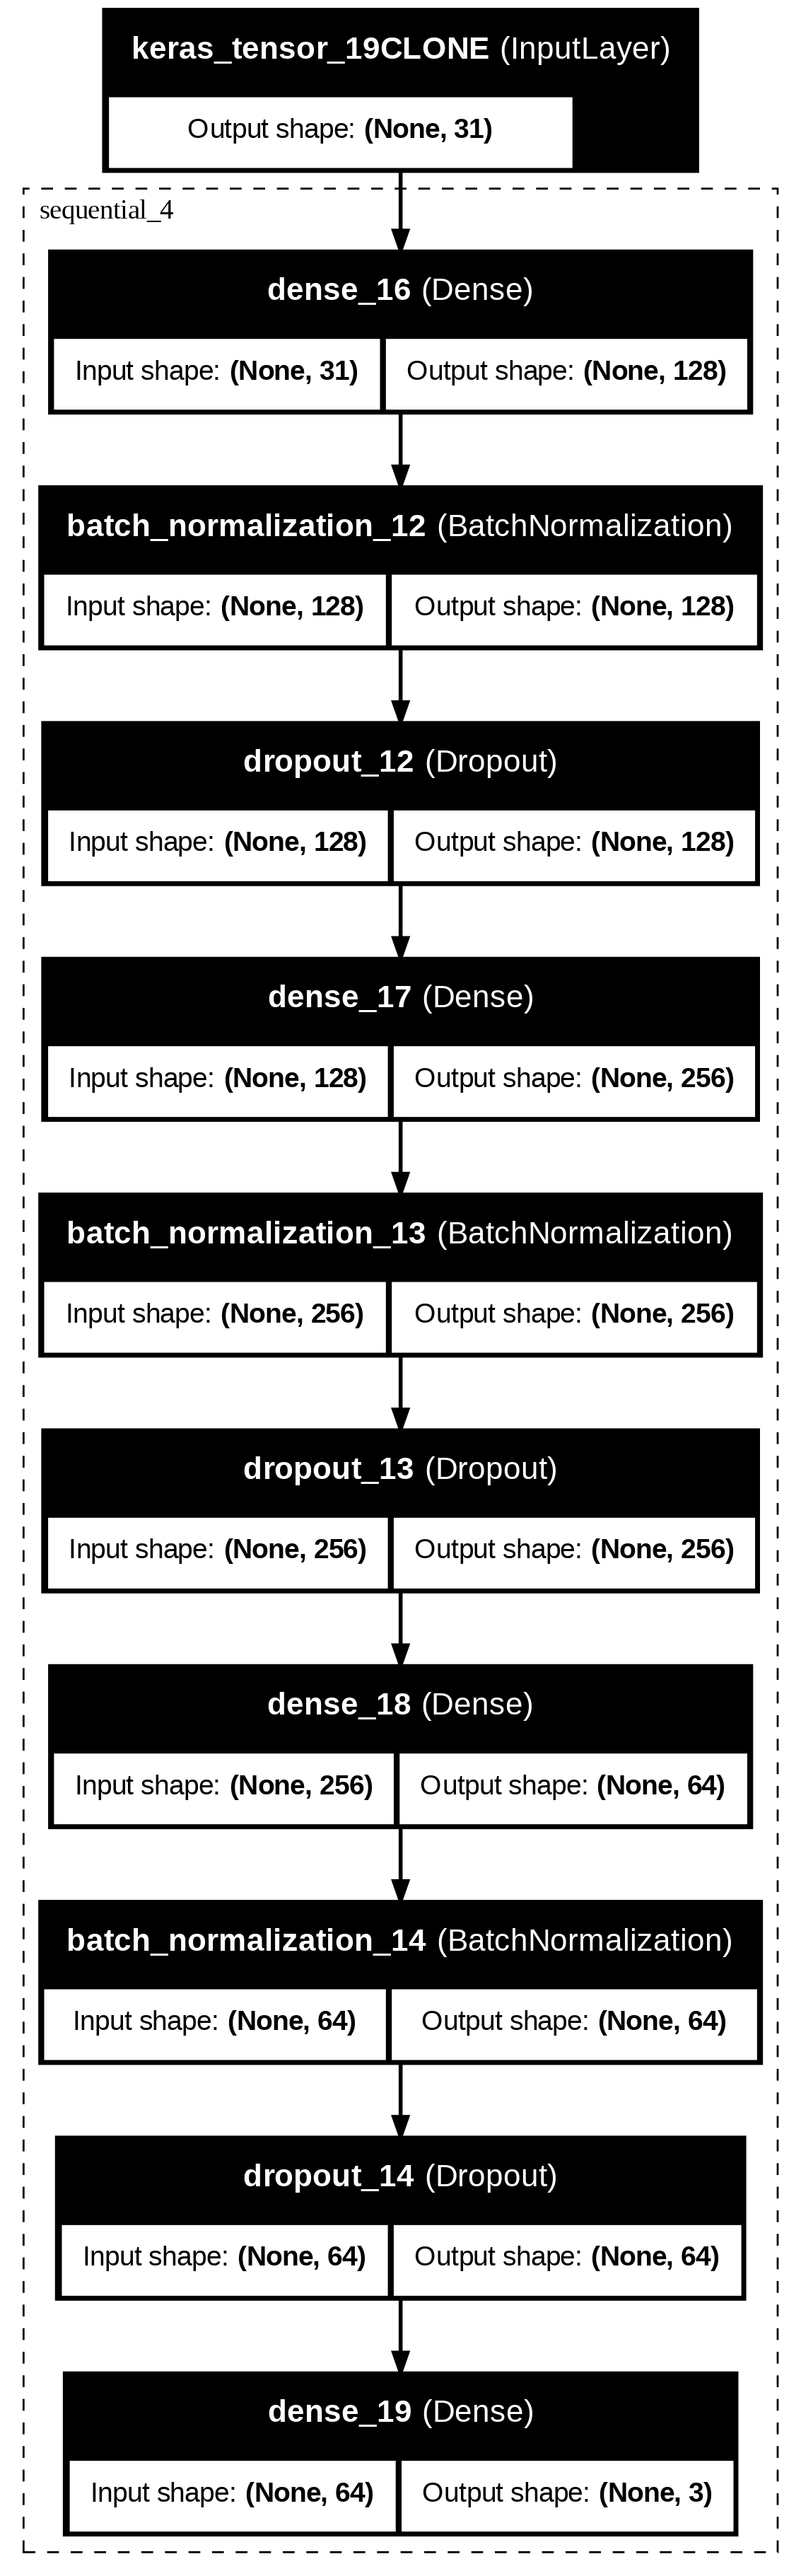

In [39]:
load_model = tf.keras.models.load_model(f"{CHECKPOINT}best_model.model.keras")

tf.keras.utils.plot_model(
    load_model,
    rankdir='TB',
    show_layer_names=True,
    show_shapes=True,
    expand_nested=True,
    # show_dtype=True,
)

# display(Image('/kaggle/working/model.png'))

  0%|          | 0/5 [00:00<?, ?it/s]

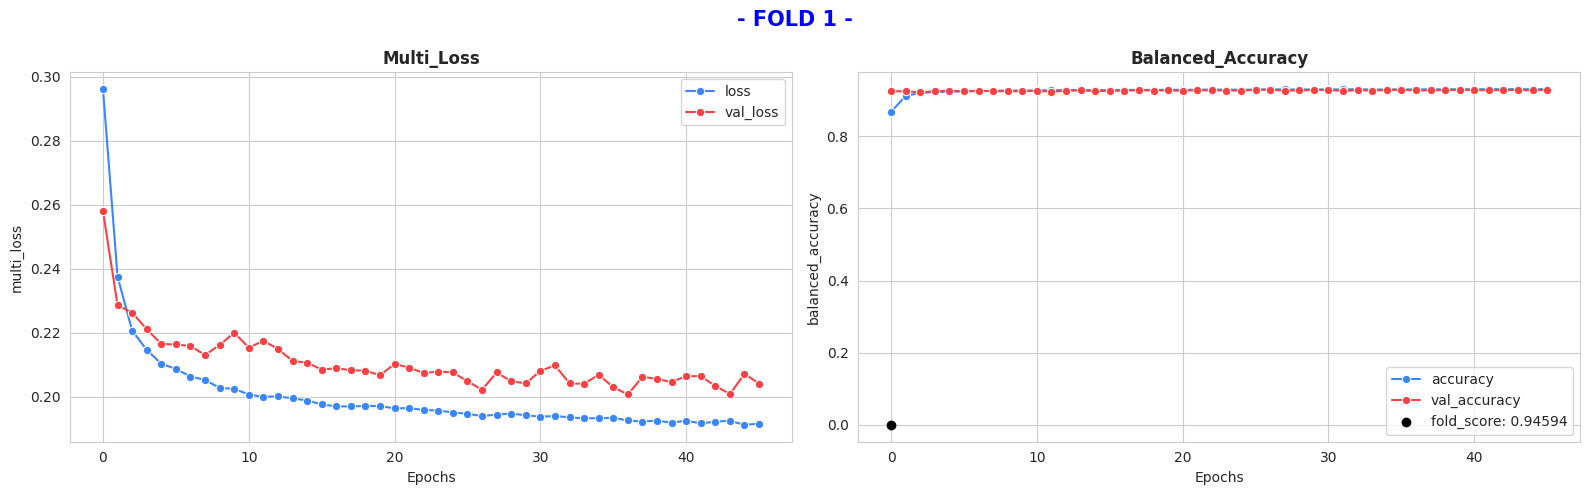

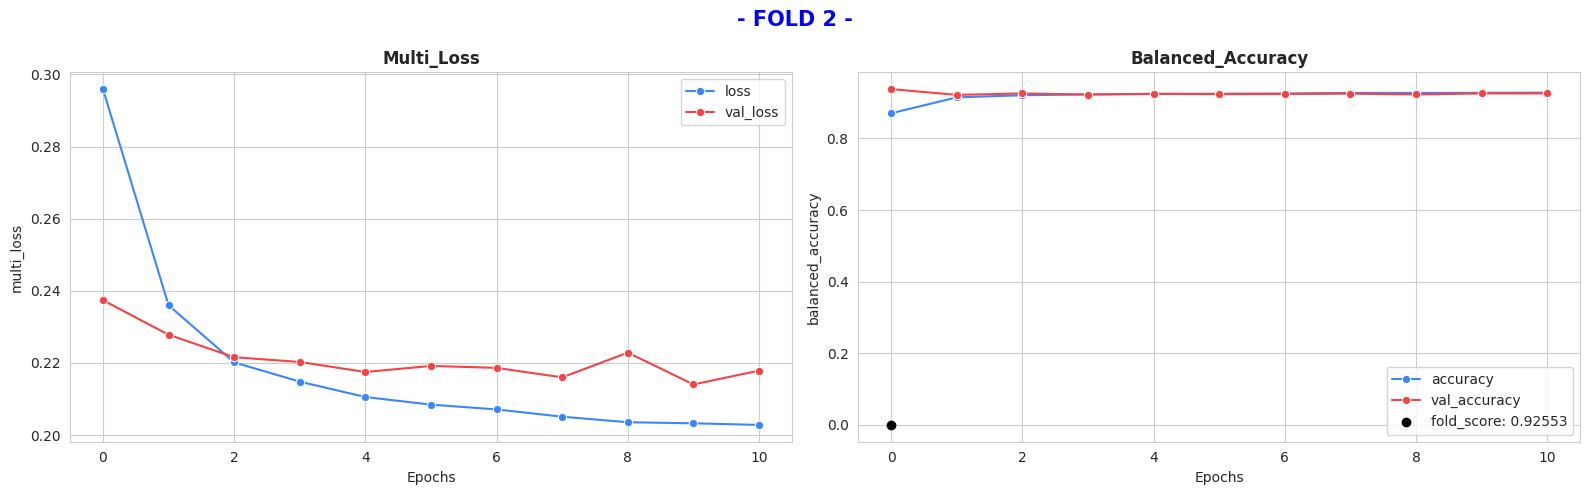

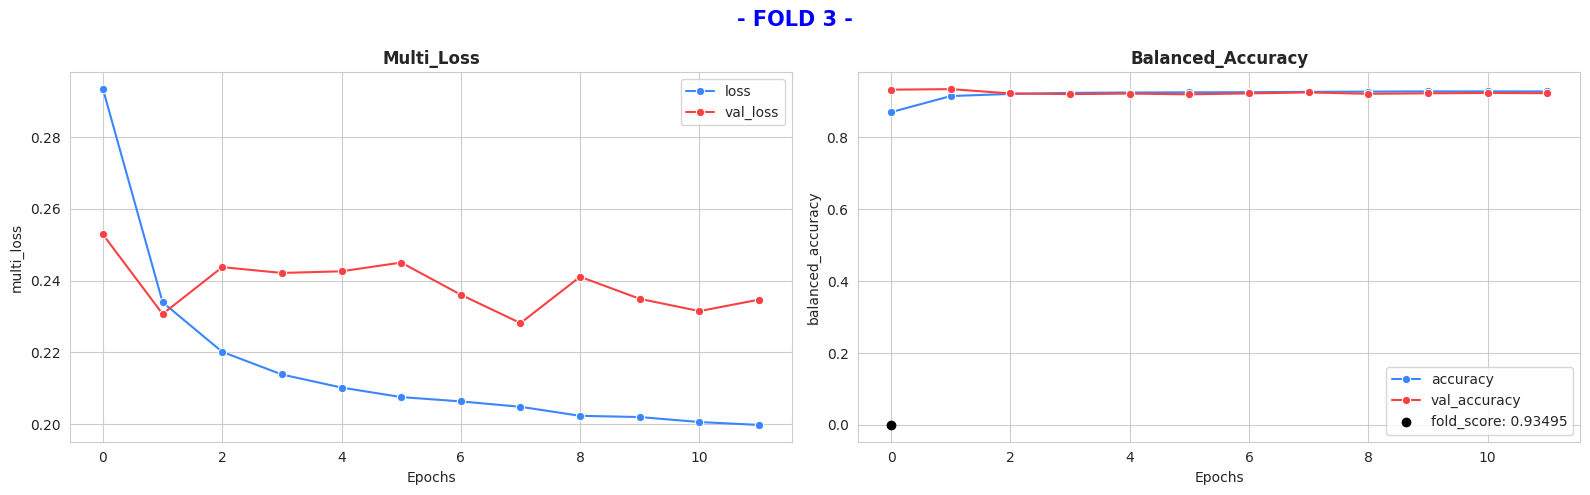

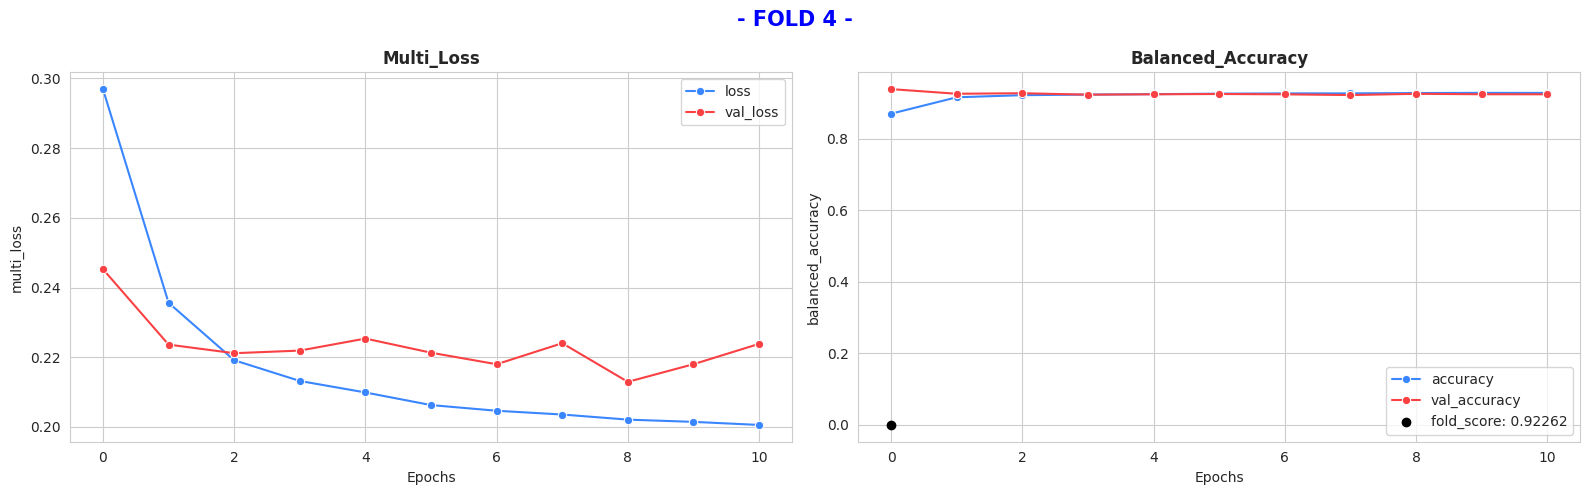

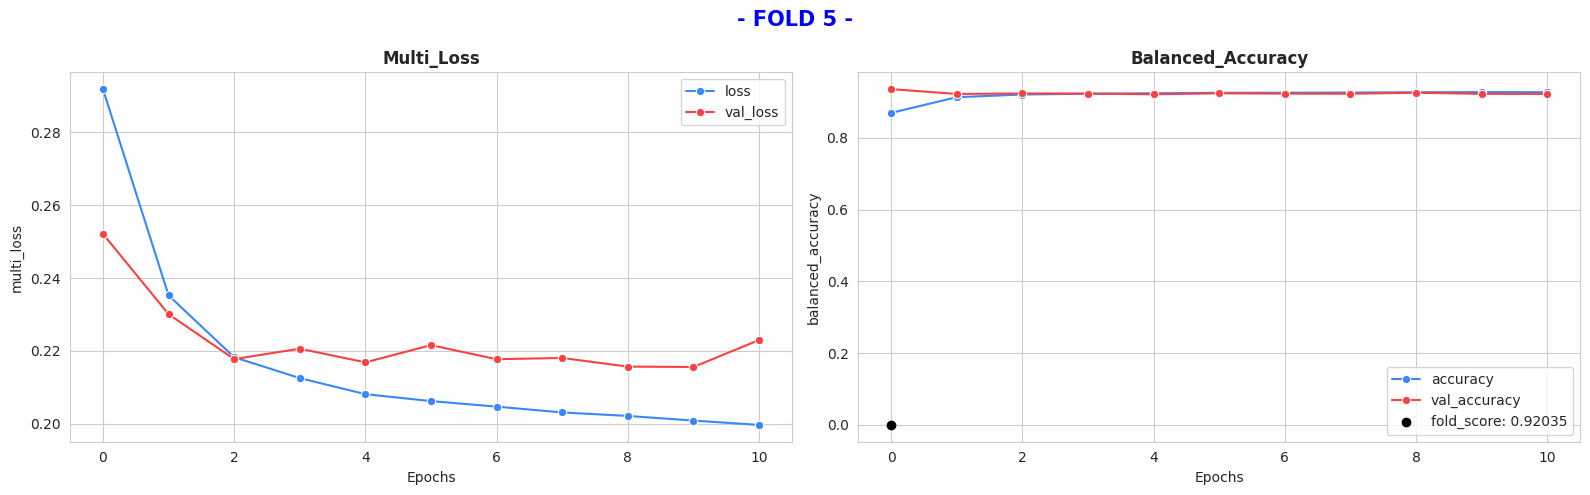

In [40]:
## -- Plot train results --

for i, data in tqdm(enumerate(result['history']), total=len(result['history'])):
    loss_results = pd.DataFrame({'loss': data['loss'], 'val_loss': data['val_loss']})
    acc_results = pd.DataFrame({'accuracy': data['accuracy'], 'val_accuracy': data['val_accuracy']})
    
    plt.figure(figsize=(16, 5))
    marker = 'o'

    ## -- PLOT 1: LOSS --
    plt.subplot(121)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.loss, label='loss', marker=marker)
    sns.lineplot(loss_results, x=loss_results.index, y=loss_results.val_loss, label='val_loss', marker=marker)
    plt.title('Multi_Loss', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('multi_loss')

    ## -- PLOT 2: ACCURACY --
    plt.subplot(122)
    sns.lineplot(acc_results, x=acc_results.index, y=acc_results.accuracy, label='accuracy', marker=marker)
    sns.lineplot(acc_results, x=acc_results.index, y=acc_results.val_accuracy, label='val_accuracy', marker=marker)
    plt.title('Balanced_Accuracy', fontweight='semibold')
    plt.xlabel('Epochs')
    plt.ylabel('balanced_accuracy')

    stat_ = f"fold_score: {result['fold_scores'][i]:.5f}"
    plt.scatter(x=0, y=0, label=stat_, color='k')

    plt.suptitle(f"- FOLD {i+1} -", fontsize=15, fontweight='semibold', color='b')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    print()

In [41]:
n = f"{VERS}_{str(result['oof_score']).split('.')[1]}"

np.save(f"oof_{n}_.npy", result['oof_preds'])
np.save(f"test_{n}_.npy", result['test_preds'])

submit[TARGET] = pd.Series(np.argmax(result['test_preds'], axis=1)).map(r_mapping)
submit.to_csv(f"submit_{n}.csv", index=False)

print(f"oof/test/submission files {CFG['YELLOW']}{n}{CFG['RESET']} saved!")
submit

oof/test/submission files kerasFS_92988 saved!


,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,at-risk
295751,985839,at-risk


In [42]:
# !rm -r /kaggle/working